In [11]:
!pip install tf-levenberg-marquardt 

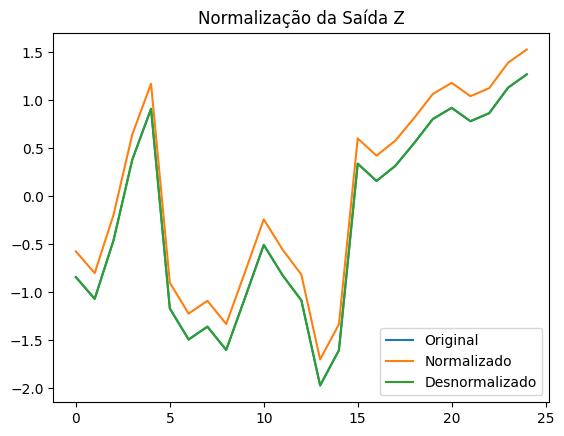

StandardScaler()

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()
input_scaler = StandardScaler()

# Função Hartmann4
def function(x):
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
 
    A = np.array([
        [10,   3, 17, 3.5],
        [0.05, 10, 17, 0.1],
        [3, 3.5, 1.7, 10],
        [17,   8, 0.05, 10]
    ])

    P = 1e-4 * np.array([
        [1312, 1696, 5569, 124],
        [2329, 4135, 8307, 3736],
        [2348, 1451, 3522, 2883],
        [4047, 8828, 8732, 5743]
    ])

    x = np.asarray(x)
    if np.any((x < 0) | (x > 1)):
        raise ValueError("Todos os valores de x devem estar no intervalo [0, 1].")

    diff = x - P
    exp_term = np.exp(-np.sum(A * diff**2, axis=1))
    z = (1.1 - np.dot(alpha, exp_term)) / 0.839

    x1, x2, x3, x4 = x
    return z, x1, x2, x3, x4

# Criação do DataFrame com grid 2D (x1, x2), fixando x3, x4
def create_dataframe(grid, x3=0.5, x4=0.5):
    x_vals = np.linspace(0, 1, grid)
    data = []

    for x1 in x_vals:
        for x2 in x_vals:
            z, x1, x2, x3_val, x4_val = function([x1, x2, x3, x4])
            data.append([x1, x2, x3_val, x4_val, z])

    df = pd.DataFrame(data, columns=["X1", "X2", "X3", "X4", "Z"])
    return df

# Visualização da normalização
def show_norm(df, label="function", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if plot:
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
        plt.show()
    return df_norm

# Visualizar normalização da saída Z
def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)
    plt.figure()
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='Desnormalizado')
    plt.title("Normalização da Saída Z")
    plt.legend()
    plt.show()

def split_df(df):
    _input = np.vstack([df['X1'], df['X2'], df['X3'], df['X4']]).T
    _output = np.array(df['Z'])
    return (_input, _output)


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)

_input, _output = split_df(df_25)
input_scaler.fit(_input)        

In [13]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model

In [14]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
import plotly.figure_factory as ff
import plotly.offline as py
from scipy.spatial import Delaunay
import plotly.graph_objs as go
import os


class Rebuild:
    def __init__(self):
        self.df = pd.read_excel(f"better_results.xlsx")        
        self.sup_input, self.sup_output = split_df(df_1000_norm)

    def LoadModelWeights(self, model, fileName):        
        path = f"content/models/{fileName}.keras"
        model.load_weights(path)

    def LoadPrevDataset(self, fileName):
        fileName = fileName.replace("model", "dataset")
        pos = fileName.rfind("_")
        path = f"content/dataset/{fileName[:pos]}.pkl" 
        with open(path, 'rb') as f:
            _data, _train, _vt, _val, _test = pickle.load(f)
        self._data, self._train, self._vt, self._val, self._test = _data, _train, _vt, _val, _test    
    
    def setArchitecture(self, _hidden_sizes, _pg, _lr):
        shuffler = ShuffleArchitecture(input_size = 4,
                                    hidden_sizes = _hidden_sizes,
                                    output_size = 1,
                                    act_h = 'tanh',
                                    act_o = 'linear',
                                    param_reg = _pg)
        shuffler.set_architecture()
        return(shuffler.create_model(_lr))            

    def getArchitecture(self, architecture):
        hidden_size = [int(x) for x in architecture.split("[")[1].split("]")[0].split(", ")]
        regularizer = float(architecture.split("regularizer=")[1].split(",")[0])
        learning_rate = float(architecture.split("learning_rate=")[1])
        return hidden_size, regularizer, learning_rate

    def PlotResults(self, original_values, predicted_values):
        titles = ['Original vs. Preditos (Completo)',
                    'Original vs. Preditos (Teste)',
                    'Original vs. Preditos (Validação)',
                    'Original vs. Preditos (Validação e Teste)']
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        for i, ax in enumerate(axes.flat):
            ax.plot(original_values[i], label='Original')
            ax.plot(predicted_values[i], label='Preditos')
            ax.set_title(titles[i])
            ax.legend()
        plt.tight_layout()
        plt.show()


    def predictResults(self, idx=-1):
        pred = self.lm_model.predict(self._data[0]).flatten()
        test_pred = self.lm_model.predict(self._test[0]).flatten()
        val_pred = self.lm_model.predict(self._val[0]).flatten()
        vt_pred = self.lm_model.predict(self._vt[0]).flatten()
        sup_pred = self.lm_model.predict(self.sup_input).flatten()

        # Calculando as metricas com a saida desnormalizada
        pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
        test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
        val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
        vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
        sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

        out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
        test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
        val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
        vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))
        sup_denorm = out_scaler.inverse_transform(self.sup_output.reshape(-1, 1))

        original_values = [out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm]
        predicted_values = [pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm]

        if (idx != -1):
            self.RecalcMetrics(idx,
                                out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm,
                                pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm)            
        return (original_values, predicted_values)

    def rebuildFullNet(self, model):
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            if model == file_model:
                hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
                self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
                self.LoadModelWeights(self.lm_model, file_model)
                self.LoadPrevDataset(file_model)
                original_values, predicted_values = self.predictResults()
                self.PlotResults(original_values, predicted_values)

    def create_dataset(self, input, output):
        input = tf.expand_dims(input, tf.float32)
        output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
        dataset = tf.data.Dataset.from_tensor_slices((input, output))
        dataset = dataset.shuffle(len(input))
        dataset = dataset.batch(1000).cache()
        dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
        return (dataset, input, output)


    def LoadNewDataset(self, grid=4, x3=0.5, x4=0.5):
        # 1. Gera grid 2D para x1 e x2
        vals = np.linspace(0, 1, grid)
        x1, x2 = np.meshgrid(vals, vals, indexing="ij")
        x1 = x1.flatten()
        x2 = x2.flatten()

        # 2. x3 e x4 fixos para todas as amostras
        x3 = np.full_like(x1, x3)
        x4 = np.full_like(x2, x4)

        # 3. Empilha tudo em input_data: shape (N, 4)
        input_data = np.vstack([x1, x2, x3, x4]).T

        # 4. Parâmetros da função Hartmann-4D
        alpha = np.array([1.0, 1.2, 3.0, 3.2])
        A = np.array([
            [10,   3, 17, 3.5],
            [0.05, 10, 17, 0.1],
            [3, 3.5, 1.7, 10],
            [17,   8, 0.05, 10]
        ])
        P = 1e-4 * np.array([
            [1312, 1696, 5569, 124],
            [2329, 4135, 8307, 3736],
            [2348, 1451, 3522, 2883],
            [4047, 8828, 8732, 5743]
        ])

        # 5. Calcula z para cada ponto
        z = np.array([
            (1.1 - np.dot(alpha, np.exp(-np.sum(A * (x - P)**2, axis=1)))) / 0.839
            for x in input_data
        ])

        # 6. Cria DataFrame
        dataset = pd.DataFrame(input_data, columns=["x1", "x2", "x3", "x4"])
        dataset["z"] = z

        return input_data, dataset

    def mean_std(self, df):
        df_out = df.iloc[:, 2:]
        print(df)
        mean = df_out.mean(axis=1)
        std = df_out.std(axis=1)
        df["media"] = mean
        df["desvio padrao"] = std
        display(df)
        df.to_excel('results.xlsx', index=False)

    def TestNewData(self):
        input, df = self.LoadNewDataset()
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
            self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
            self.LoadModelWeights(self.lm_model, file_model)
            pred = self.lm_model.predict(input).flatten()
            pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
            df[file_model] = pred_denorm
        self.mean_std(df)
        df.to_excel
            
                


In [15]:
Rebuilder = Rebuild()
Rebuilder.TestNewData()

1/1 [==============================] - 0s 29ms/step


/tmp/ipykernel_27319/639254309.py:169: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_27319/639254309.py:169: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



1/1 [==============================] - 0s 22ms/step


/tmp/ipykernel_27319/639254309.py:169: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_27319/639254309.py:169: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



1/1 [==============================] - 0s 34ms/step


...

1/1 [==============================] - 0s 78ms/step


/tmp/ipykernel_27319/639254309.py:169: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



1/1 [==============================] - 0s 54ms/step
          x1        x2   x3   x4         z  model_15_5_2  model_15_5_3  \
0   0.000000  0.000000  0.5  0.5 -0.841402     -1.628979     -1.636454   
1   0.000000  0.333333  0.5  0.5 -0.945868     -1.852973     -1.857920   
2   0.000000  0.666667  0.5  0.5  0.125026     -2.062096     -2.067349   
3   0.000000  1.000000  0.5  0.5  0.908902     -2.080772     -2.084376   
4   0.333333  0.000000  0.5  0.5 -1.020655     -0.793323     -0.803935   
5   0.333333  0.333333  0.5  0.5 -1.380469     -0.844533     -0.852914   
6   0.333333  0.666667  0.5  0.5 -2.048462     -0.858266     -0.865558   
7   0.333333  1.000000  0.5  0.5 -1.847693     -0.808622     -0.814048   
8   0.666667  0.000000  0.5  0.5  0.075026      0.024315      0.016531   
9   0.666667  0.333333  0.5  0.5 -0.132124      0.194701      0.191040   
10  0.666667  0.666667  0.5  0.5 -0.071821      0.368417      0.366860   
11  0.666667  1.000000  0.5  0.5  0.203076      0.518068    

/tmp/ipykernel_27319/639254309.py:169: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_27319/639254309.py:156: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_27319/639254309.py:157: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



,x1,x2,x3,x4,z,model_15_5_2,model_15_5_3,model_22_8_15,model_22_8_14,model_22_8_16,...,model_2_7_3,model_2_7_0,model_6_6_11,model_2_7_4,model_33_9_0,model_2_7_5,model_21_7_3,model_6_6_10,media,desvio padrao
0,0.000000,0.000000,0.5,0.5,-0.841402,-1.628979,-1.636454,-1.128822,-1.128985,-1.128667,...,-1.306094,-1.287066,0.321518,-1.312537,-1.080001,-1.318976,-1.976595,0.329059,-1.100466,0.537620
1,0.000000,0.333333,0.5,0.5,-0.945868,-1.852973,-1.857920,-1.470734,-1.470866,-1.470610,...,-1.896120,-1.873464,-0.096855,-1.903552,-1.204141,-1.910862,-2.396703,-0.088636,-1.445267,0.567937
2,0.000000,0.666667,0.5,0.5,0.125026,-2.062096,-2.067349,-2.022066,-2.021782,-2.022341,...,-2.294695,-2.286599,-0.529826,-2.297539,-1.551682,-2.300398,-2.670482,-0.523158,-1.839635,0.575719
3,0.000000,1.000000,0.5,0.5,0.908902,-2.080772,-2.084376,-2.315739,-2.314611,-2.316815,...,-2.312906,-2.300880,-0.643561,-2.316906,-1.763260,-2.320852,-2.608619,-0.641361,-2.014340,0.607196
4,0.333333,0.000000,0.5,0.5,-1.020655,-0.793323,-0.803935,-0.598085,-0.598585,-0.597611,...,-1.005964,-0.996971,1.166864,-1.008803,-0.620129,-1.011492,-0.896202,1.168663,-0.400217,0.578389
5,0.333333,0.333333,0.5,0.5,-1.380469,-0.844533,-0.852914,-0.880390,-0.880842,-0.879964,...,-1.268137,-1.280507,1.025299,-1.264435,-0.537263,-1.260873,-1.071674,1.027684,-0.575892,0.612260
6,0.333333,0.666667,0.5,0.5,-2.048462,-0.858266,-0.865558,-1.284223,-1.284297,-1.284158,...,-1.266848,-1.270928,0.794468,-1.265752,-0.551872,-1.264727,-1.071470,0.796424,-0.756698,0.635891
7,0.333333,1.000000,0.5,0.5,-1.847693,-0.808622,-0.814048,-1.360628,-1.360018,-1.361210,...,-1.196087,-1.178076,0.732563,-1.201845,-0.579001,-1.207437,-0.832791,0.733622,-0.826338,0.610046
8,0.666667,0.000000,0.5,0.5,0.075026,0.024315,0.016531,-0.044761,-0.045211,-0.044334,...,-0.171210,-0.183453,1.381338,-0.167500,0.105605,-0.163943,0.159091,1.379995,0.129294,0.414155
9,0.666667,0.333333,0.5,0.5,-0.132124,0.194701,0.191040,-0.090488,-0.090845,-0.090149,...,-0.038994,-0.052345,1.454677,-0.034907,0.431020,-0.030986,0.276252,1.453187,0.213094,0.423653
